## Importations


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import re
import time
from difflib import SequenceMatcher

In [2]:


df = pd.read_csv('HRDataset_v14.csv')
dfTerm = df[df['Termd'] != 0]
dfTerm.drop(columns=['Termd'], inplace=True)
dfIn = df[df['Termd'] != 1]
dfIn.drop(columns=['Termd'], inplace=True)
dfIn.drop(columns=['TermReason'],inplace = True)
df['DateofHire'] = pd.to_datetime(df['DateofHire'], errors="coerce")
df['DateofTermination'] = pd.to_datetime(df['DateofTermination'], errors="coerce")
df['LastPerformanceReview_Date'] = pd.to_datetime(df['LastPerformanceReview_Date'], errors="coerce")


/tmp/ipykernel_7350/1908006578.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfTerm.drop(columns=['Termd'], inplace=True)
/tmp/ipykernel_7350/1908006578.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfIn.drop(columns=['Termd'], inplace=True)
/tmp/ipykernel_7350/1908006578.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfIn.drop(columns=['TermReason'],inplace = True)


In [3]:
most_recent_termination = df['DateofTermination'].max()
most_recent_termination

Timestamp('2018-11-10 00:00:00')

In [4]:
most_recent_hire = df['DateofHire'].max()
most_recent_hire

Timestamp('2018-07-09 00:00:00')

In [5]:
most_recent_review = df['LastPerformanceReview_Date'].max()
most_recent_review

Timestamp('2019-02-28 00:00:00')

In [6]:
today = max(most_recent_hire,most_recent_termination, most_recent_review)
today

Timestamp('2019-02-28 00:00:00')

In [7]:
seniority_end_date = df['DateofTermination'].where(df['Termd'] == 1, today)
df['Seniority_Days'] = (seniority_end_date - df['DateofHire']).dt.days


In [8]:
df.head(10)

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences,Seniority_Days
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,22.0,LinkedIn,Exceeds,4.60,5,0,2019-01-17,0,1,2795
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,4.0,Indeed,Fully Meets,4.96,3,6,2016-02-24,0,17,444
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,20.0,LinkedIn,Fully Meets,3.02,3,0,2012-05-15,0,3,447
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,16.0,Indeed,Fully Meets,4.84,5,0,2019-01-03,0,15,4070
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,39.0,Google Search,Fully Meets,5.00,4,0,2016-02-01,0,2,1884
5,"Anderson, Linda",10002,0,0,0,1,5,4,0,57568,...,11.0,LinkedIn,Exceeds,5.00,5,0,2019-01-07,0,15,2607
6,"Andreola, Colby",10194,0,0,0,1,4,3,0,95660,...,10.0,LinkedIn,Fully Meets,3.04,3,4,2019-01-02,0,19,1571
7,"Athwal, Sam",10062,0,4,1,1,5,3,0,59365,...,19.0,Employee Referral,Fully Meets,5.00,4,0,2019-02-25,0,19,1977
8,"Bachiochi, Linda",10114,0,0,0,3,5,3,1,47837,...,12.0,Diversity Job Fair,Fully Meets,4.46,3,0,2019-01-25,0,4,3524
9,"Bacong, Alejandro",10250,0,2,1,1,3,3,0,50178,...,7.0,Indeed,Fully Meets,5.00,5,6,2019-02-18,0,16,1515


In [9]:
df.shape

(311, 37)

In [10]:
dfTerm.shape

(104, 35)

In [11]:
df.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB',
       'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences', 'Seniority_Days'],
      dtype='object')

In [12]:
term_details = dfTerm['TermReason']

In [13]:
term_details.shape

(104,)

In [14]:
term_details.head(5)

,TermReason
1,career change
2,hours
4,return to school
10,Another position
11,unhappy


In [15]:
valeurs_uniques = term_details.unique()

In [16]:
len(valeurs_uniques)

17

In [17]:
valeurs_uniques

array(['career change', 'hours', 'return to school', 'Another position',
       'unhappy', 'attendance', 'performance',
       'Learned that he is a gangster', 'retiring',
       'relocation out of area', 'more money', 'military',
       'no-call, no-show', 'Fatal attraction',
       'maternity leave - did not return', 'medical issues',
       'gross misconduct'], dtype=object)

TermReason est catégorisé en 17 Raisons différentes

## Data Understanding

/tmp/ipykernel_7350/4015517797.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  corr_df[col] = pd.to_datetime(corr_df[col], errors="coerce")


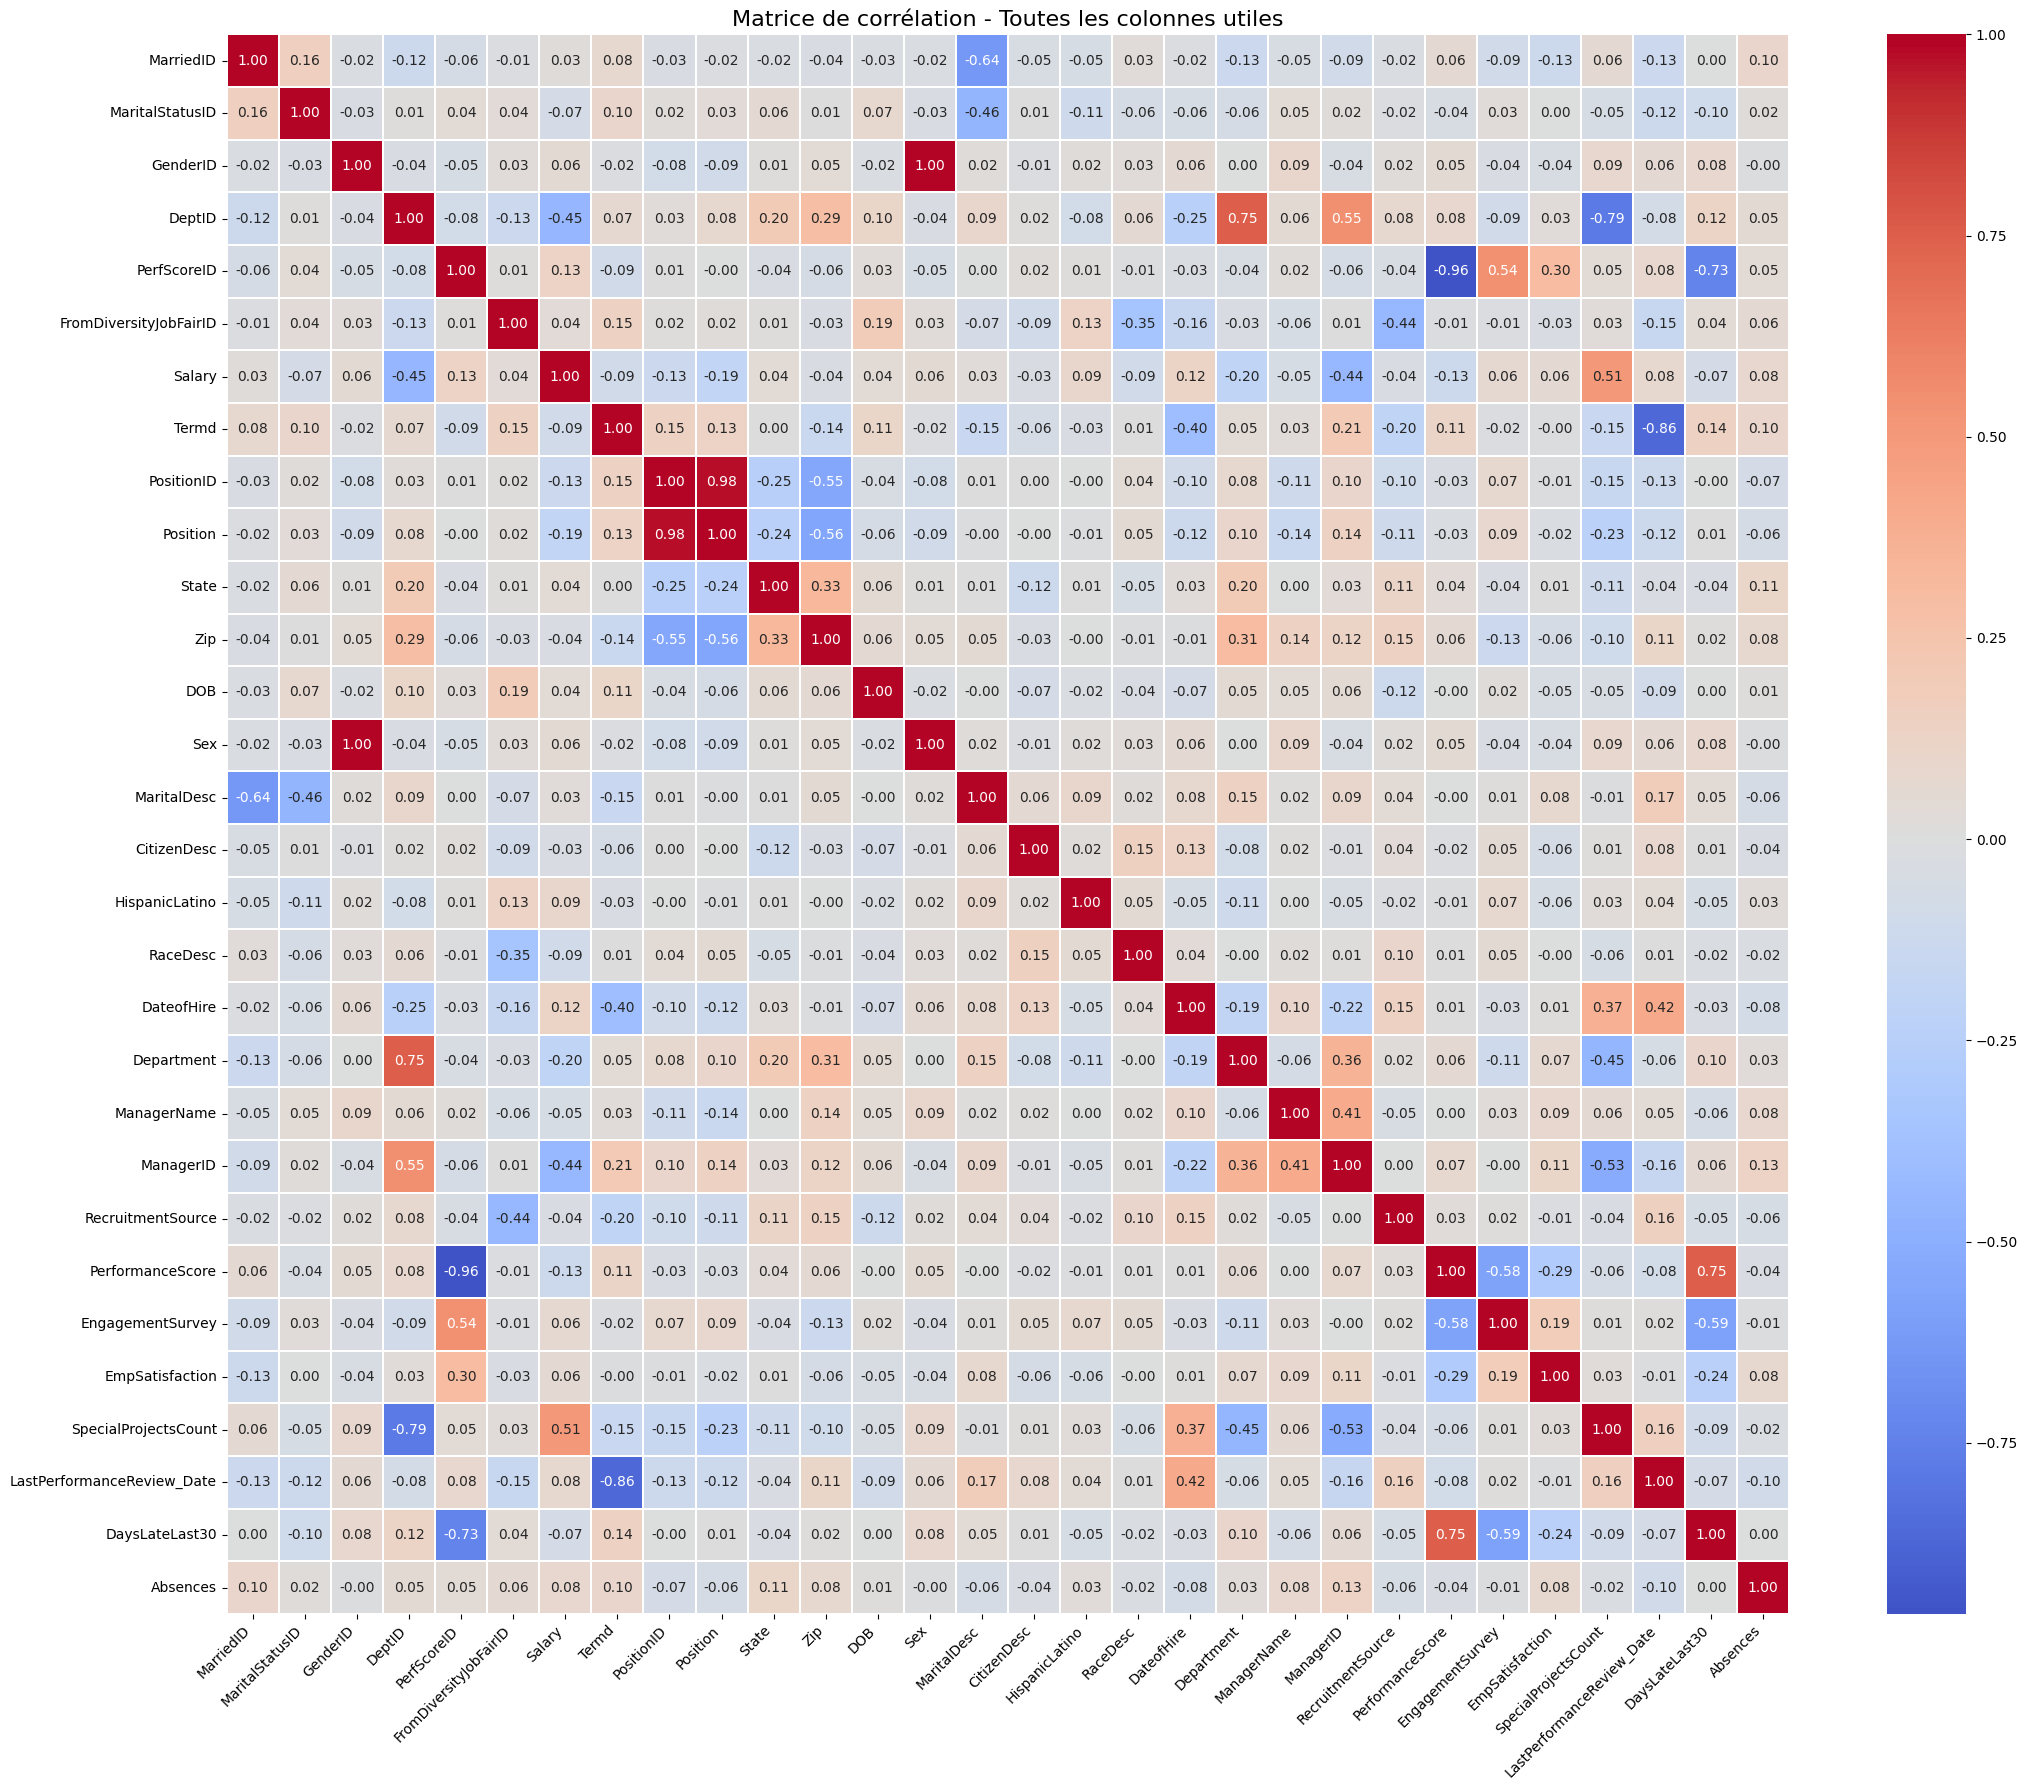


Corrélations avec Termd (triées) :
Termd                         1.000000
ManagerID                     0.209113
FromDiversityJobFairID        0.147717
PositionID                    0.147042
DaysLateLast30                0.136379
Position                      0.128687
PerformanceScore              0.112317
DOB                           0.107070
MaritalStatusID               0.099367
Absences                      0.098274
MarriedID                     0.077028
DeptID                        0.065922
Department                    0.047477
ManagerName                   0.032512
RaceDesc                      0.010249
State                         0.004940
EmpSatisfaction              -0.004732
GenderID                     -0.015741
Sex                          -0.015741
EngagementSurvey             -0.017543
HispanicLatino               -0.033744
CitizenDesc                  -0.062140
PerfScoreID                  -0.089061
Salary                       -0.093994
Zip                         

In [18]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

excluded_cols = [
    "TermReason",
    "DateofTermination",
    "EmploymentStatus",
    "EmpStatusID",
    "Employee_Name",
    "EmpID",
    "Seniority_Days"
]

excluded_cols = [col for col in excluded_cols if col in df.columns]
corr_df = df.drop(columns=excluded_cols).copy()
date_cols = ["DOB", "DateofHire", "LastPerformanceReview_Date"]
for col in date_cols:
    if col in corr_df.columns:
        corr_df[col] = pd.to_datetime(corr_df[col], errors="coerce")
        corr_df[col] = corr_df[col].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)


for col in corr_df.select_dtypes(include="object").columns:
    corr_df[col] = corr_df[col].astype("category").cat.codes


corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(22, 18))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Matrice de corrélation - Toutes les colonnes utiles", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

if "Termd" in corr_matrix.columns:
    print("\nCorrélations avec Termd (triées) :")
    print(corr_matrix["Termd"].sort_values(ascending=False))
else:
    print("La colonne 'Termd' n'est pas présente dans la matrice.")

print("\nColonnes exclues :")
print(excluded_cols)

print("\nColonnes incluses dans la matrice :")
print(list(corr_df.columns))


--- Turnover Rate by MaritalStatusID ---
MaritalStatusID
2    0.533333
4    0.500000
1    0.379032
0    0.262774
3    0.083333
Name: Termd, dtype: float64


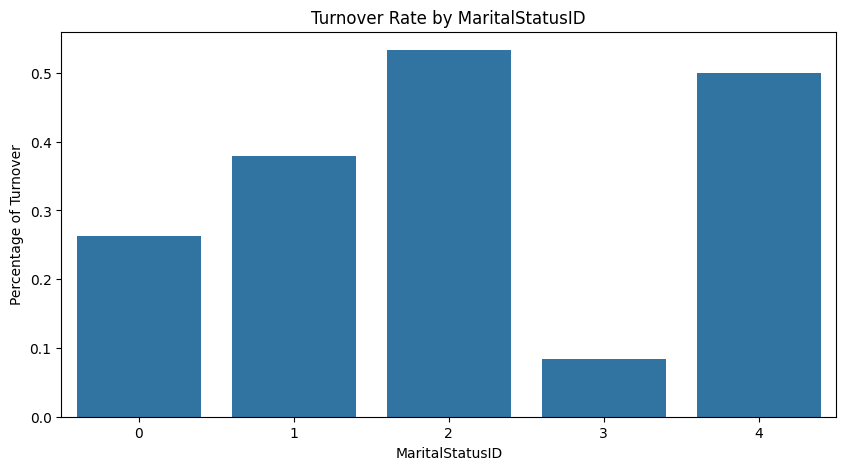


--- Turnover Rate by EmpStatusID ---
EmpStatusID
5    1.00000
4    1.00000
1    0.01087
3    0.00000
2    0.00000
Name: Termd, dtype: float64


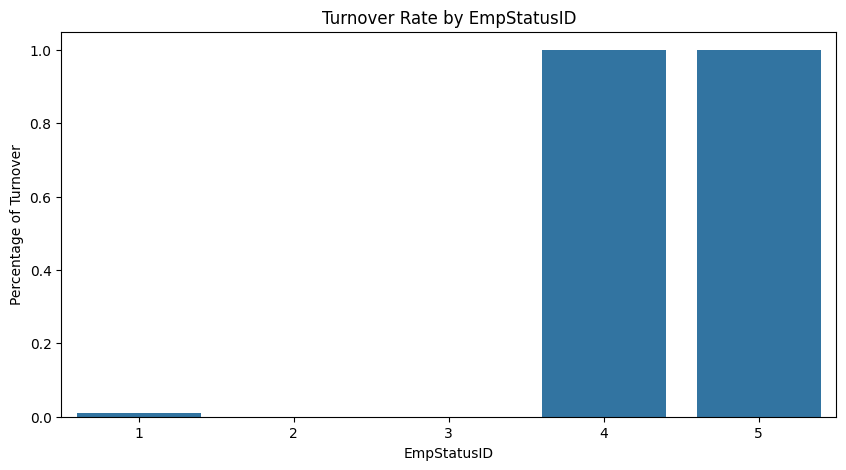


--- Turnover Rate by DeptID ---
DeptID
5    0.399038
1    0.300000
4    0.300000
3    0.200000
6    0.156250
2    0.000000
Name: Termd, dtype: float64


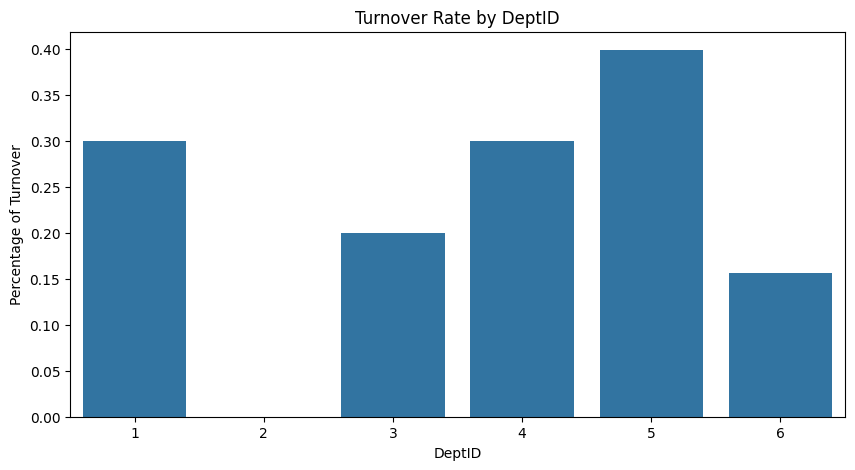


--- Turnover Rate by PerfScoreID ---
PerfScoreID
2    0.555556
3    0.337449
1    0.307692
4    0.216216
Name: Termd, dtype: float64


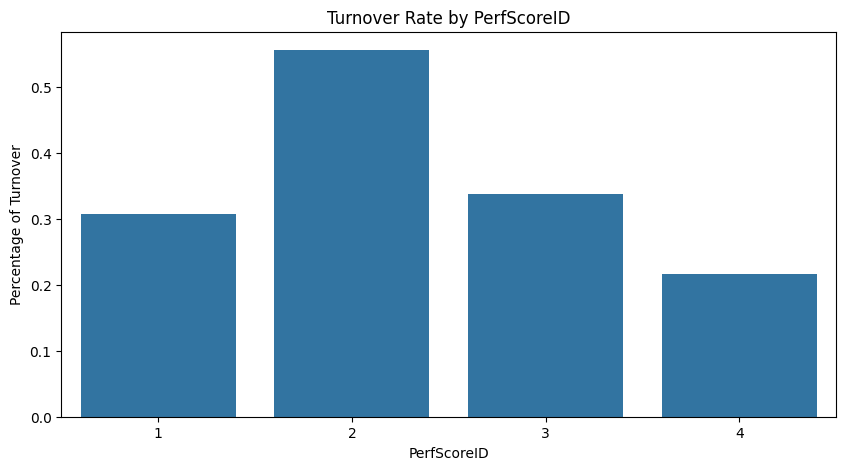


--- Turnover Rate by FromDiversityJobFairID ---
FromDiversityJobFairID
1    0.551724
0    0.312057
Name: Termd, dtype: float64


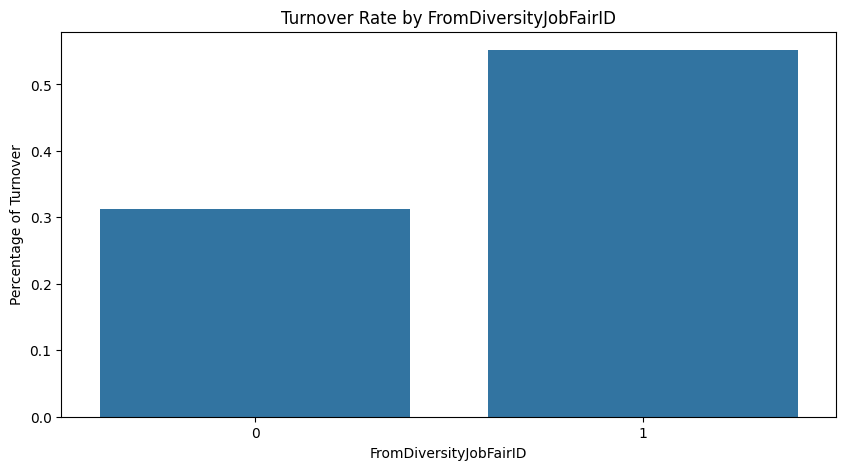


--- Turnover Rate by PositionID ---
PositionID
29    1.000000
30    1.000000
2     0.666667
8     0.600000
23    0.500000
27    0.500000
20    0.456140
18    0.384615
19    0.379562
21    0.333333
24    0.333333
9     0.250000
13    0.250000
15    0.200000
3     0.148148
14    0.000000
11    0.000000
10    0.000000
7     0.000000
4     0.000000
5     0.000000
6     0.000000
1     0.000000
12    0.000000
16    0.000000
17    0.000000
22    0.000000
25    0.000000
26    0.000000
28    0.000000
Name: Termd, dtype: float64


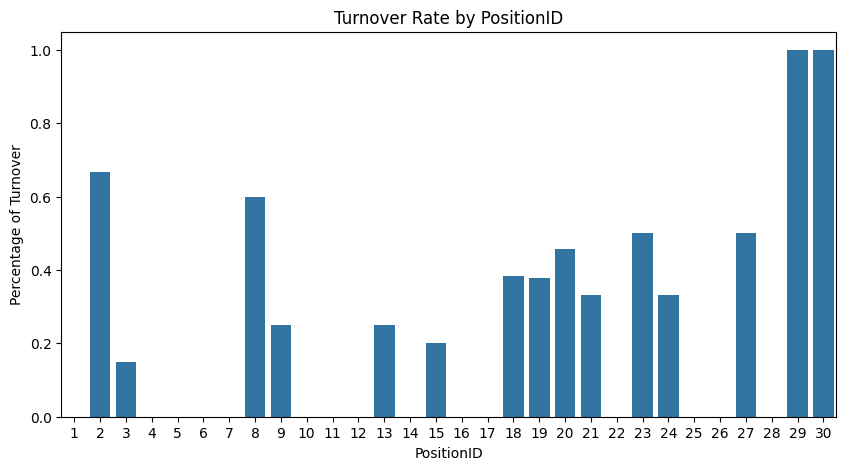


--- Turnover Rate by Position ---
Position
Enterprise Architect            1.000000
Principal Data Architect        1.000000
Administrative Assistant        0.666667
Database Administrator          0.600000
IT Manager - DB                 0.500000
Sr. DBA                         0.500000
Production Technician II        0.456140
Software Engineer               0.400000
Production Technician I         0.379562
Production Manager              0.357143
Sales Manager                   0.333333
Data Analyst                    0.250000
Network Engineer                0.200000
Area Sales Manager              0.148148
Accountant I                    0.000000
IT Manager - Infra              0.000000
IT Director                     0.000000
Director of Operations          0.000000
Director of Sales               0.000000
Data Architect                  0.000000
BI Developer                    0.000000
BI Director                     0.000000
CIO                             0.000000
IT Support   

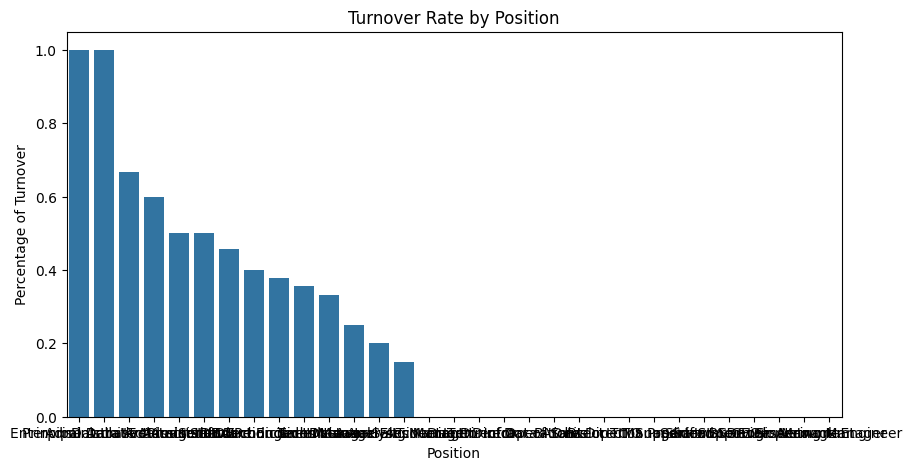


--- Turnover Rate by Zip ---
Zip
1420     1.0
1742     1.0
1876     1.0
1851     1.0
2492     1.0
        ... 
85006    0.0
89139    0.0
90007    0.0
97756    0.0
98052    0.0
Name: Termd, Length: 158, dtype: float64


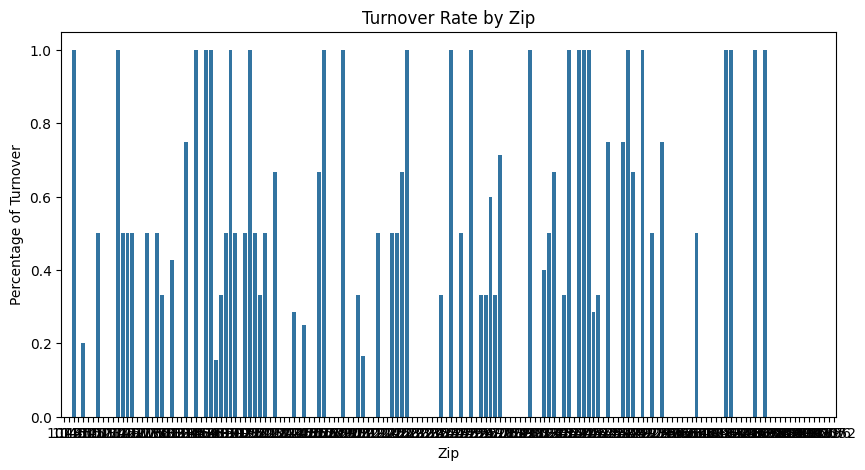


--- Turnover Rate by DOB ---
DOB
01/07/74    1.0
12/31/84    1.0
12/08/73    1.0
12/10/86    1.0
12/17/87    1.0
           ... 
12/09/86    0.0
12/08/83    0.0
12/05/74    0.0
12/03/76    0.0
01/02/51    0.0
Name: Termd, Length: 307, dtype: float64


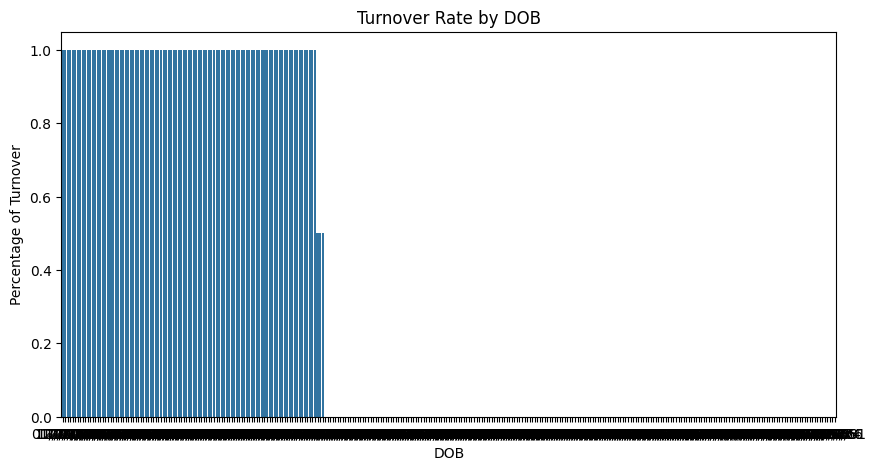


--- Turnover Rate by Sex ---
Sex
F    0.340909
M    0.325926
Name: Termd, dtype: float64


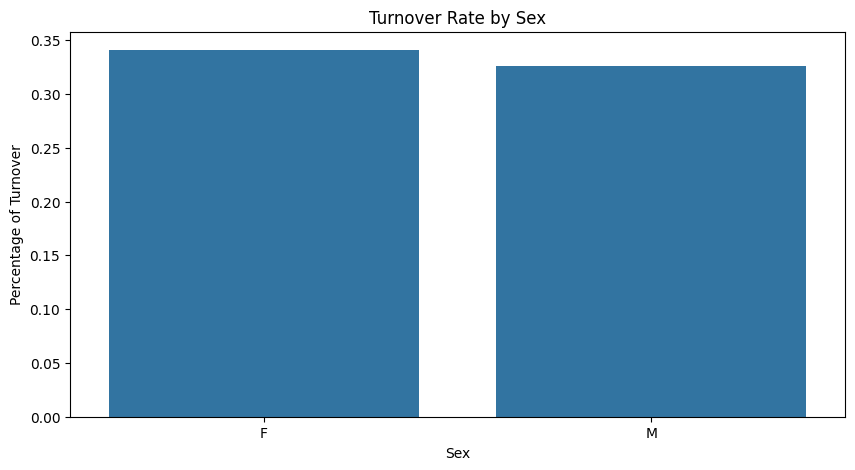


--- Turnover Rate by MaritalDesc ---
MaritalDesc
Divorced     0.533333
Widowed      0.500000
Married      0.379032
Single       0.262774
Separated    0.083333
Name: Termd, dtype: float64


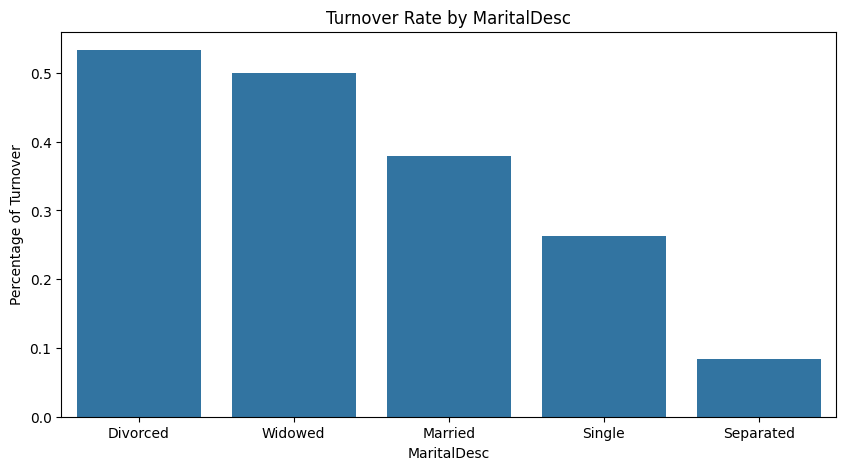


--- Turnover Rate by CitizenDesc ---
CitizenDesc
Non-Citizen            0.750000
Eligible NonCitizen    0.416667
US Citizen             0.325424
Name: Termd, dtype: float64


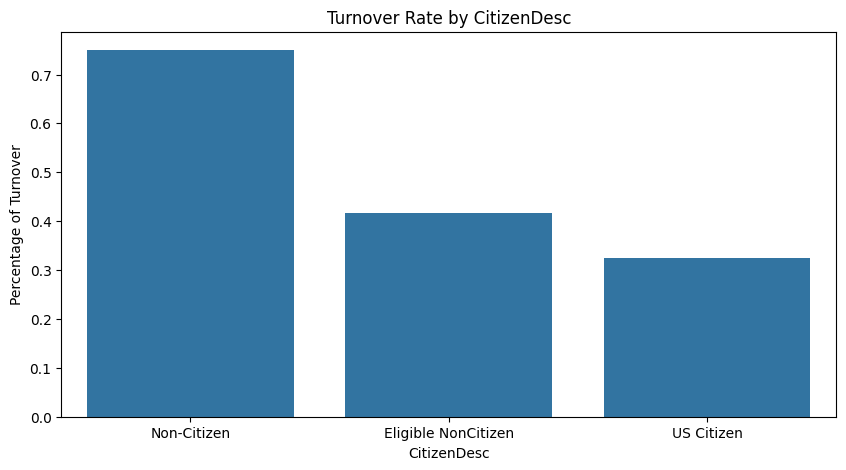


--- Turnover Rate by HispanicLatino ---
HispanicLatino
No     0.336879
Yes    0.333333
no     0.000000
yes    0.000000
Name: Termd, dtype: float64


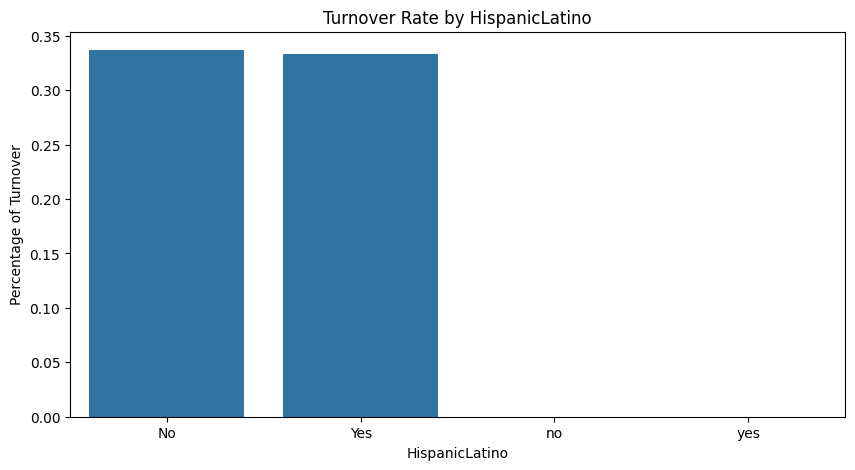


--- Turnover Rate by RaceDesc ---
RaceDesc
Black or African American           0.362500
White                               0.336898
Asian                               0.310345
Two or more races                   0.272727
American Indian or Alaska Native    0.000000
Hispanic                            0.000000
Name: Termd, dtype: float64


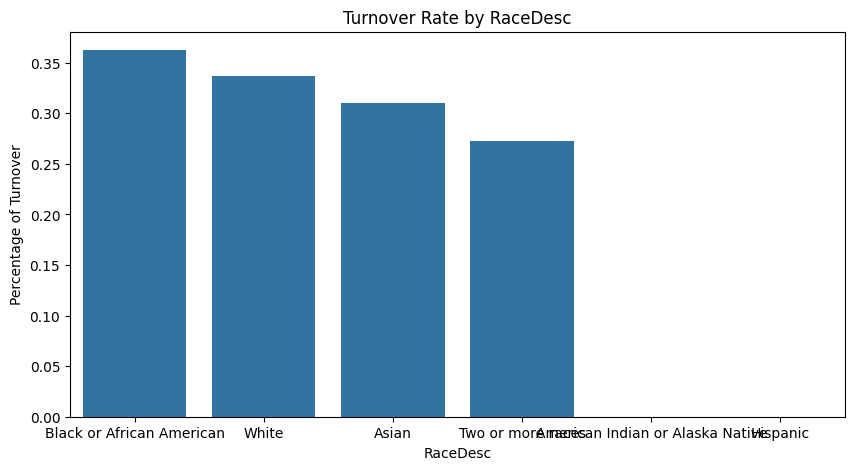


--- Turnover Rate by DateofHire ---
DateofHire
2007-06-25    1.0
2008-09-02    1.0
2010-10-25    1.0
2009-10-26    1.0
2009-04-27    1.0
             ... 
2017-01-07    0.0
2017-02-10    0.0
2017-02-15    0.0
2017-04-20    0.0
2018-07-09    0.0
Name: Termd, Length: 101, dtype: float64


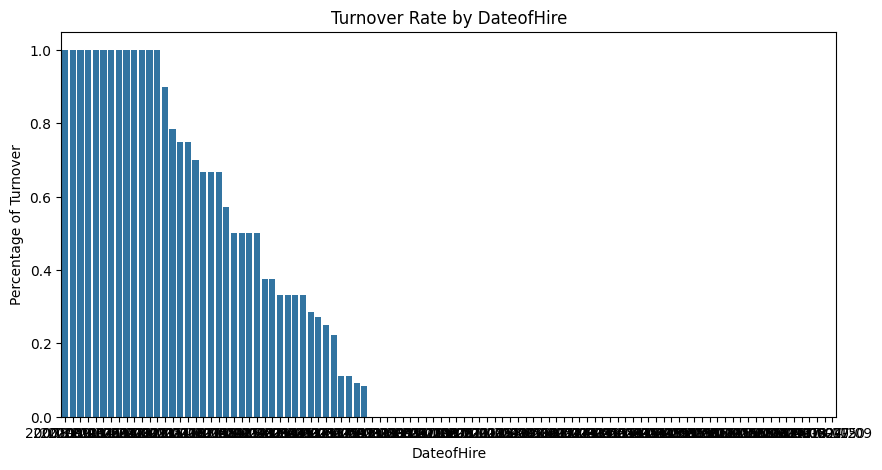


--- Turnover Rate by EmploymentStatus ---
EmploymentStatus
Terminated for Cause      1.0
Voluntarily Terminated    1.0
Active                    0.0
Name: Termd, dtype: float64


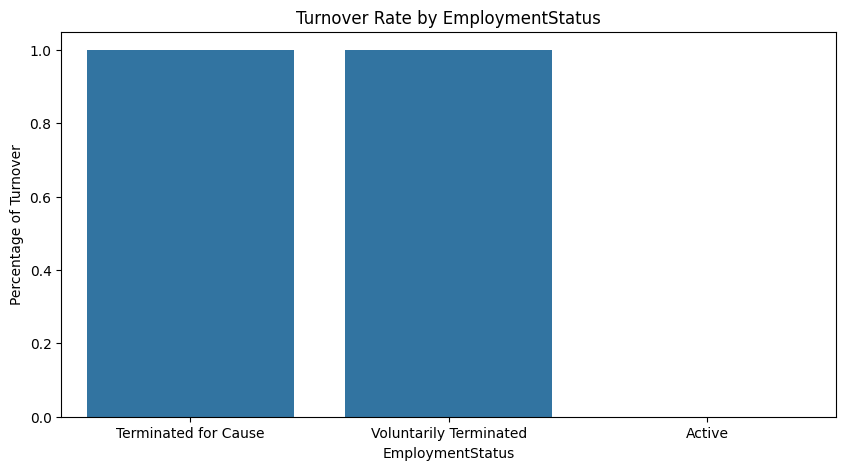


--- Turnover Rate by Department ---
Department
Production              0.397129
Software Engineering    0.363636
Admin Offices           0.222222
IT/IS                   0.200000
Sales                   0.161290
Executive Office        0.000000
Name: Termd, dtype: float64


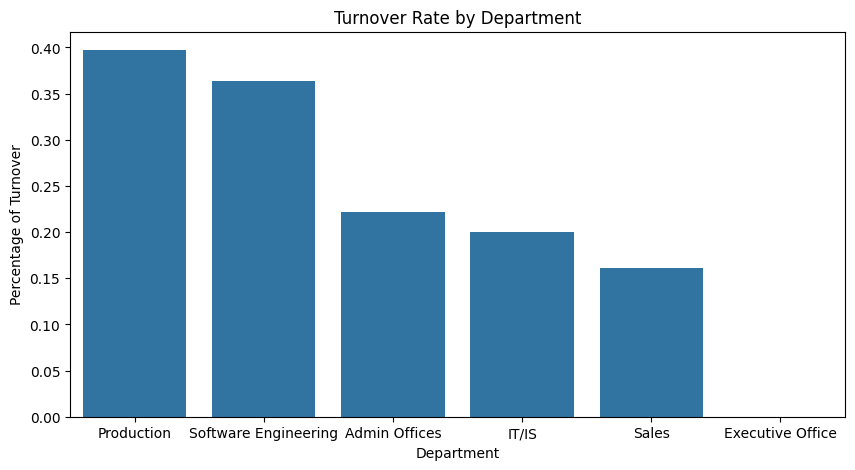


--- Turnover Rate by ManagerName ---
ManagerName
Amy Dunn              0.619048
Webster Butler        0.619048
Kissy Sullivan        0.545455
Simon Roup            0.470588
Michael Albert        0.409091
Elijiah Gray          0.363636
Debra Houlihan        0.333333
Alex Sweetwater       0.333333
Janet King            0.315789
Brandon R. LeBlanc    0.285714
David Stanley         0.285714
Kelley Spirea         0.272727
Brannon Miller        0.272727
Ketsia Liebig         0.238095
John Smith            0.214286
Jennifer Zamora       0.142857
Lynn Daneault         0.076923
Peter Monroe          0.071429
Board of Directors    0.000000
Eric Dougall          0.000000
Brian Champaigne      0.000000
Name: Termd, dtype: float64


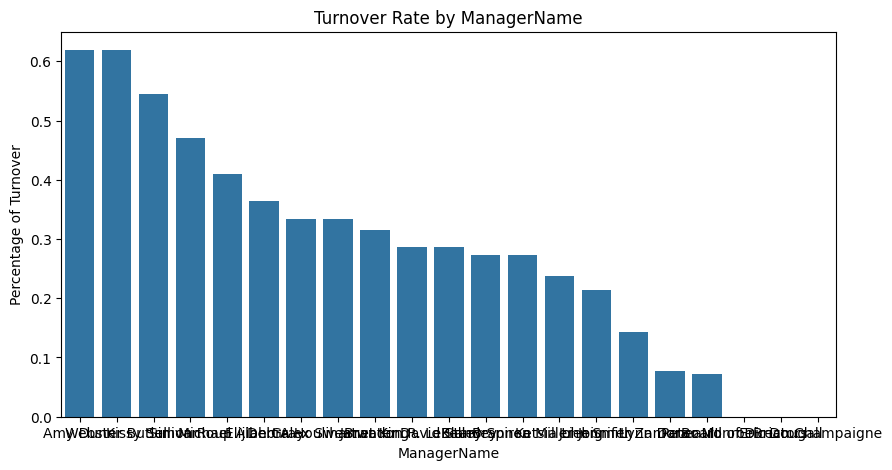


--- Turnover Rate by ManagerID ---
ManagerID
39.0    1.000000
30.0    1.000000
11.0    0.619048
20.0    0.545455
4.0     0.470588
22.0    0.380952
16.0    0.363636
15.0    0.333333
1.0     0.333333
10.0    0.333333
2.0     0.315789
14.0    0.285714
18.0    0.272727
12.0    0.272727
19.0    0.238095
17.0    0.214286
5.0     0.142857
21.0    0.076923
7.0     0.071429
6.0     0.000000
3.0     0.000000
13.0    0.000000
9.0     0.000000
Name: Termd, dtype: float64


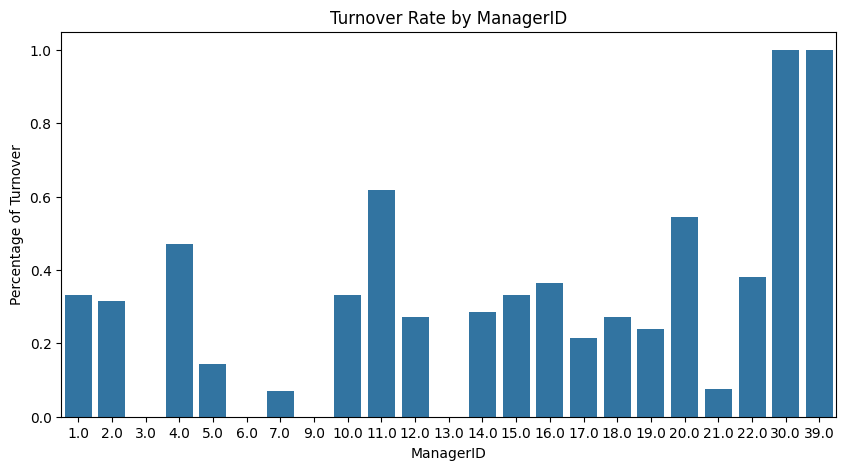


--- Turnover Rate by RecruitmentSource ---
RecruitmentSource
On-line Web application    1.000000
Google Search              0.612245
Diversity Job Fair         0.551724
Other                      0.500000
CareerBuilder              0.478261
Indeed                     0.241379
LinkedIn                   0.236842
Employee Referral          0.161290
Website                    0.076923
Name: Termd, dtype: float64


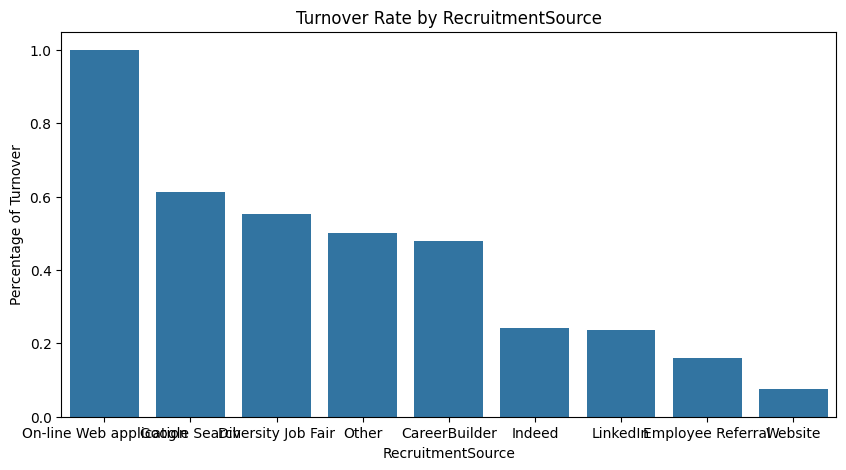


--- Turnover Rate by PerformanceScore ---
PerformanceScore
Needs Improvement    0.555556
PIP                  0.384615
Fully Meets          0.333333
Exceeds              0.216216
Name: Termd, dtype: float64


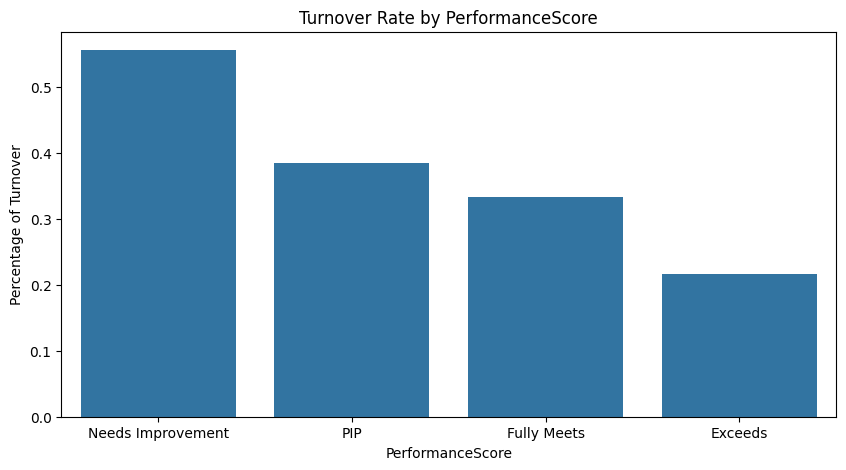


--- Turnover Rate by EngagementSurvey ---
EngagementSurvey
2.10    1.0
2.34    1.0
3.02    1.0
3.03    1.0
2.50    1.0
       ... 
4.73    0.0
4.84    0.0
4.83    0.0
4.81    0.0
4.94    0.0
Name: Termd, Length: 119, dtype: float64


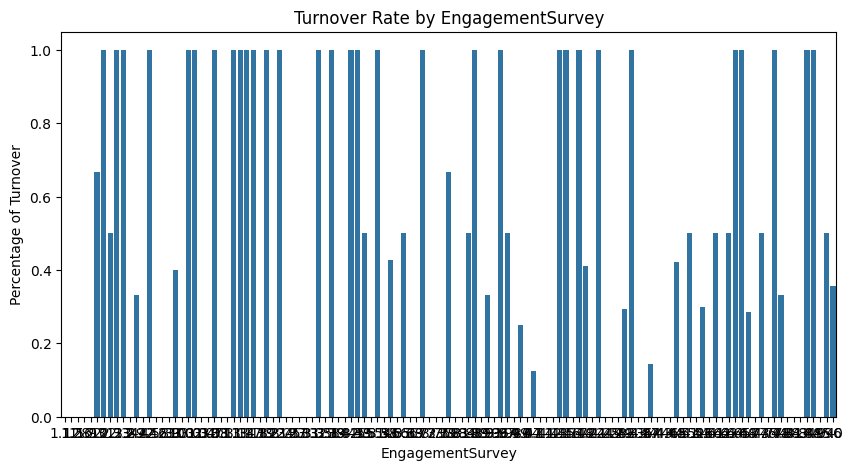


--- Turnover Rate by EmpSatisfaction ---
EmpSatisfaction
2    0.444444
4    0.404255
3    0.305556
5    0.295918
1    0.000000
Name: Termd, dtype: float64


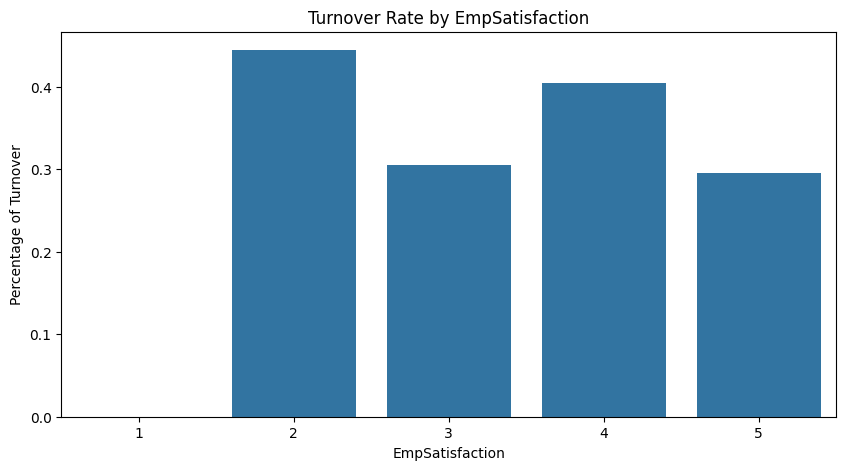


--- Turnover Rate by SpecialProjectsCount ---
SpecialProjectsCount
4    0.555556
0    0.369295
3    0.333333
7    0.250000
5    0.190476
6    0.095238
2    0.000000
1    0.000000
8    0.000000
Name: Termd, dtype: float64


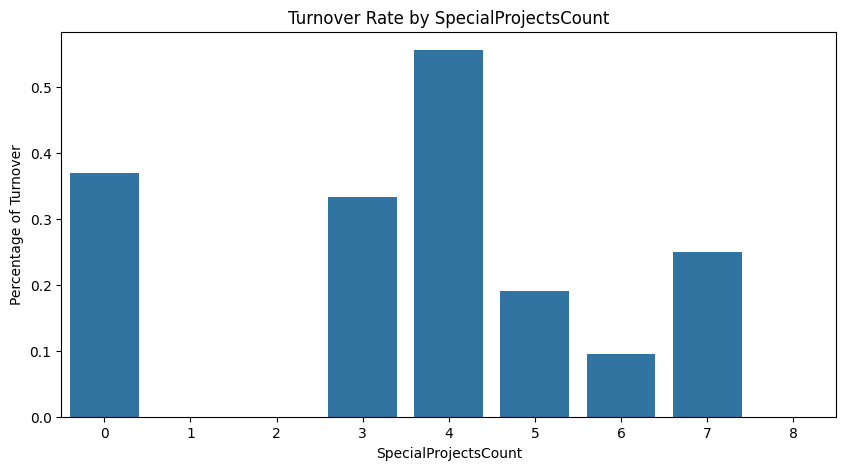


--- Turnover Rate by LastPerformanceReview_Date ---
LastPerformanceReview_Date
2010-07-14    1.0
2011-02-06    1.0
2011-03-06    1.0
2011-05-04    1.0
2011-10-22    1.0
             ... 
2019-02-22    0.0
2019-02-25    0.0
2019-02-26    0.0
2019-02-27    0.0
2019-02-28    0.0
Name: Termd, Length: 137, dtype: float64


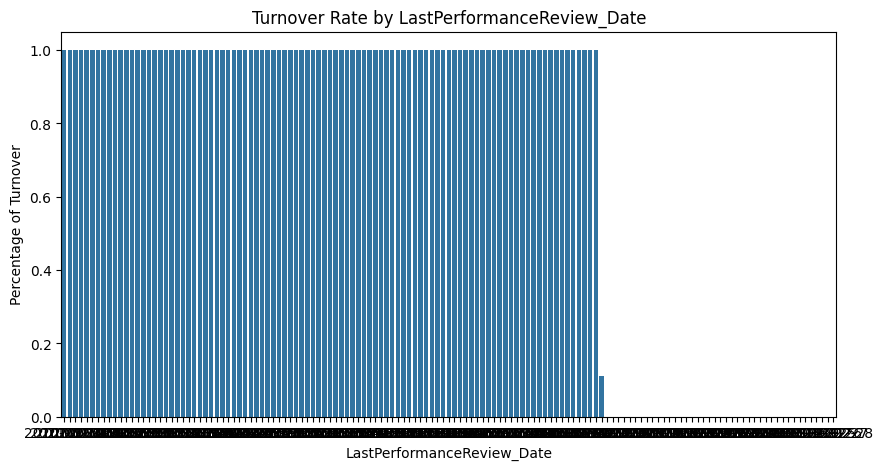


--- Turnover Rate by DaysLateLast30 ---
DaysLateLast30
1    1.000000
5    0.833333
3    0.500000
4    0.500000
6    0.500000
0    0.316547
2    0.000000
Name: Termd, dtype: float64


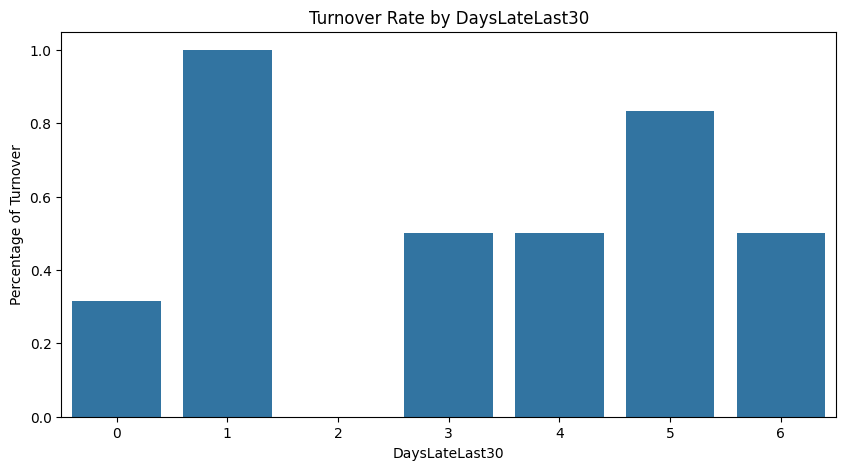


--- Turnover Rate by Absences ---
Absences
16    0.478261
17    0.466667
6     0.437500
9     0.428571
20    0.428571
10    0.400000
18    0.375000
12    0.375000
19    0.375000
15    0.350000
7     0.333333
5     0.333333
11    0.333333
2     0.285714
8     0.272727
3     0.250000
13    0.235294
4     0.217391
1     0.214286
14    0.176471
Name: Termd, dtype: float64


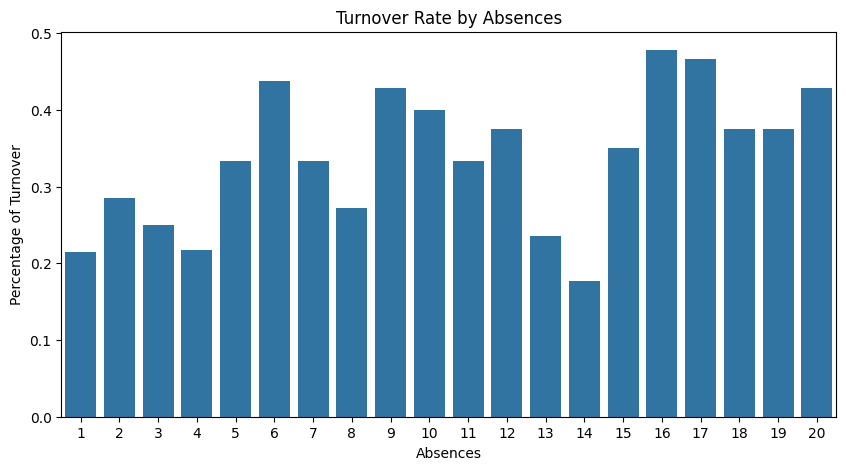


--- Missing Values Report ---
Employee_Name                   0
EmpID                           0
MarriedID                       0
MaritalStatusID                 0
GenderID                        0
EmpStatusID                     0
DeptID                          0
PerfScoreID                     0
FromDiversityJobFairID          0
Salary                          0
Termd                           0
PositionID                      0
Position                        0
State                           0
Zip                             0
DOB                             0
Sex                             0
MaritalDesc                     0
CitizenDesc                     0
HispanicLatino                  0
RaceDesc                        0
DateofHire                      0
DateofTermination             207
TermReason                      0
EmploymentStatus                0
Department                      0
ManagerName                     0
ManagerID                       8
RecruitmentSource

In [19]:
def check_bias(dataframe, protected_attribute):
    print(f"\n--- Turnover Rate by {protected_attribute} ---")
    bias_check = dataframe.groupby(protected_attribute)['Termd'].mean().sort_values(ascending=False)
    print(bias_check)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=bias_check.index, y=bias_check.values)
    plt.title(f'Turnover Rate by {protected_attribute}')
    plt.ylabel('Percentage of Turnover')
    plt.show()

columns_to_check = [ 'MaritalStatusID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'PositionID', 'Position', 'Zip', 'DOB','Sex',
       'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire','EmploymentStatus','Department', 'ManagerName', 'ManagerID',
       'RecruitmentSource','PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30','Absences']

for col in columns_to_check:
    check_bias(df, col)
print("\n--- Missing Values Report ---")
print(df.isnull().sum())

/tmp/ipykernel_7350/241174745.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  corr_df[col] = pd.to_datetime(corr_df[col], errors="coerce")


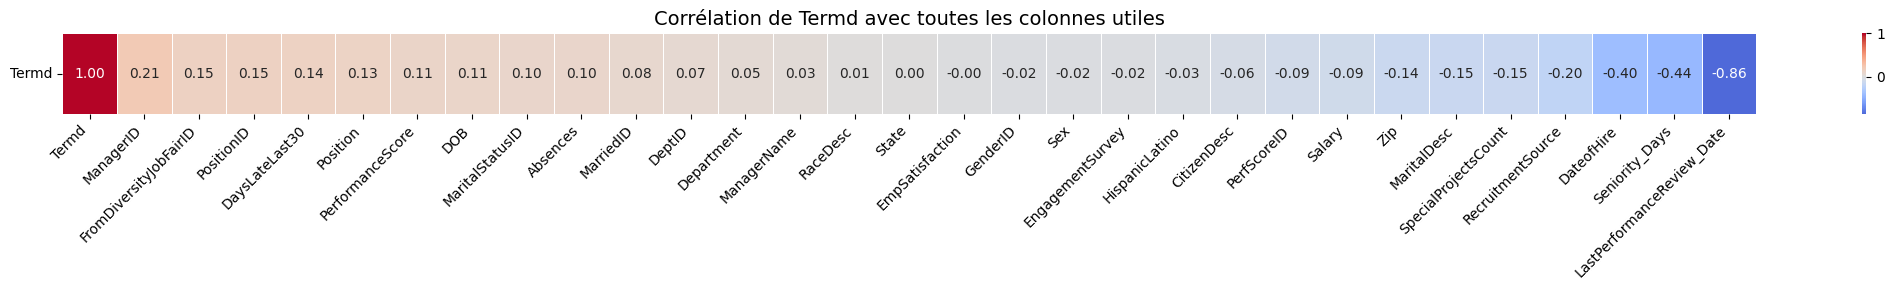


Corrélations avec Termd :
                               Termd
Termd                       1.000000
ManagerID                   0.209113
FromDiversityJobFairID      0.147717
PositionID                  0.147042
DaysLateLast30              0.136379
Position                    0.128687
PerformanceScore            0.112317
DOB                         0.107070
MaritalStatusID             0.099367
Absences                    0.098274
MarriedID                   0.077028
DeptID                      0.065922
Department                  0.047477
ManagerName                 0.032512
RaceDesc                    0.010249
State                       0.004940
EmpSatisfaction            -0.004732
GenderID                   -0.015741
Sex                        -0.015741
EngagementSurvey           -0.017543
HispanicLatino             -0.033744
CitizenDesc                -0.062140
PerfScoreID                -0.089061
Salary                     -0.093994
Zip                        -0.139006
MaritalDesc

In [20]:

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

excluded_cols = [
    "TermReason",
    "DateofTermination",
    "EmploymentStatus",
    "EmpStatusID",
    "Employee_Name",
    "EmpID"
]

excluded_cols = [col for col in excluded_cols if col in df.columns]
corr_df = df.drop(columns=excluded_cols).copy()

date_cols = ["DOB", "DateofHire", "LastPerformanceReview_Date"]
for col in date_cols:
    if col in corr_df.columns:
        corr_df[col] = pd.to_datetime(corr_df[col], errors="coerce")
        corr_df[col] = corr_df[col].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)

for col in corr_df.select_dtypes(include="object").columns:
    corr_df[col] = corr_df[col].astype("category").cat.codes

if "Termd" not in corr_df.columns:
    raise ValueError("La colonne 'Termd' n'existe pas dans le dataset.")
termd_corr = corr_df.corr(numeric_only=True)[["Termd"]].T

termd_corr = termd_corr.loc[:, termd_corr.loc["Termd"].sort_values(ascending=False).index]

plt.figure(figsize=(22, 3))
sns.heatmap(
    termd_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Corrélation de Termd avec toutes les colonnes utiles", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nCorrélations avec Termd :")
print(termd_corr.T.sort_values(by="Termd", ascending=False))

print("\nColonnes exclues :")
print(excluded_cols)

/tmp/ipykernel_7350/1151563194.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfTerm[col] = dfTerm[col].astype(str).str.strip()
/tmp/ipykernel_7350/1151563194.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfTerm[col] = dfTerm[col].astype(str).str.strip()
/tmp/ipykernel_7350/1151563194.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

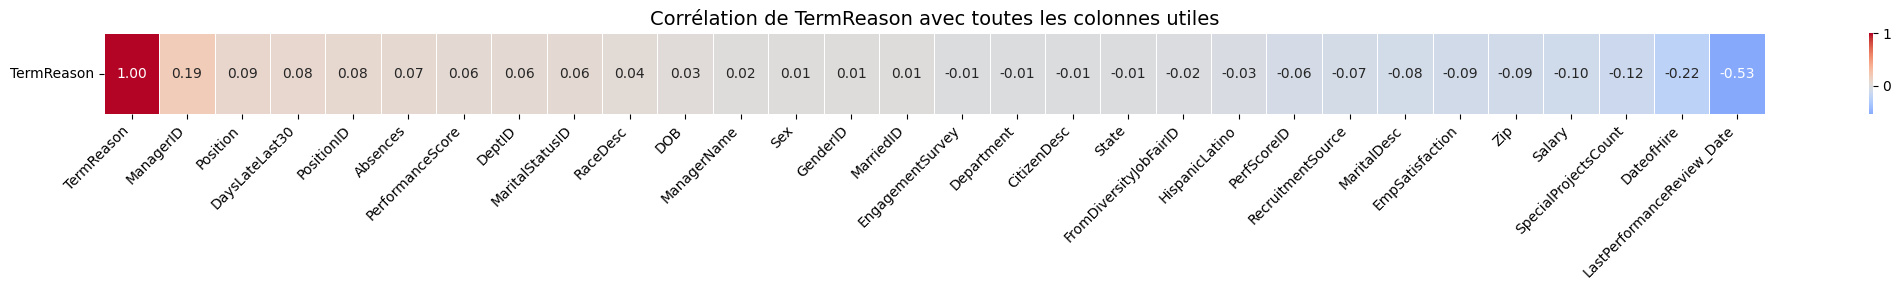


Corrélations avec TermReason :
                            TermReason
TermReason                    1.000000
ManagerID                     0.189581
Position                      0.092255
DaysLateLast30                0.081502
PositionID                    0.075422
Absences                      0.071453
PerformanceScore              0.058005
DeptID                        0.057626
MaritalStatusID               0.055300
RaceDesc                      0.044680
DOB                           0.026121
ManagerName                   0.017057
Sex                           0.008426
GenderID                      0.008426
MarriedID                     0.008115
EngagementSurvey             -0.007500
Department                   -0.009087
CitizenDesc                  -0.013473
State                        -0.013663
FromDiversityJobFairID       -0.019507
HispanicLatino               -0.030882
PerfScoreID                  -0.063070
RecruitmentSource            -0.072865
MaritalDesc                  -0.

In [21]:
for col in df.select_dtypes(include="object").columns:
    dfTerm[col] = dfTerm[col].astype(str).str.strip()

excluded_cols = [
    "Termd",
    "DateofTermination",
    "EmploymentStatus",
    "EmpStatusID",
    "Employee_Name",
    "EmpID",
    "Seniority_Days"
]

excluded_cols = [col for col in excluded_cols if col in df.columns]
corr_df = df.drop(columns=excluded_cols).copy()

date_cols = ["DOB", "DateofHire", "LastPerformanceReview_Date"]
for col in date_cols:
    if col in corr_df.columns:
        corr_df[col] = pd.to_datetime(corr_df[col], errors="coerce")
        corr_df[col] = corr_df[col].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)

for col in corr_df.select_dtypes(include="object").columns:
    corr_df[col] = corr_df[col].astype("category").cat.codes

termd_corr = corr_df.corr(numeric_only=True)[["TermReason"]].T

termd_corr = termd_corr.loc[:, termd_corr.loc["TermReason"].sort_values(ascending=False).index]

plt.figure(figsize=(22, 3))
sns.heatmap(
    termd_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Corrélation de TermReason avec toutes les colonnes utiles", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nCorrélations avec TermReason :")
print(termd_corr.T.sort_values(by="TermReason", ascending=False))

print("\nColonnes exclues :")
print(excluded_cols)

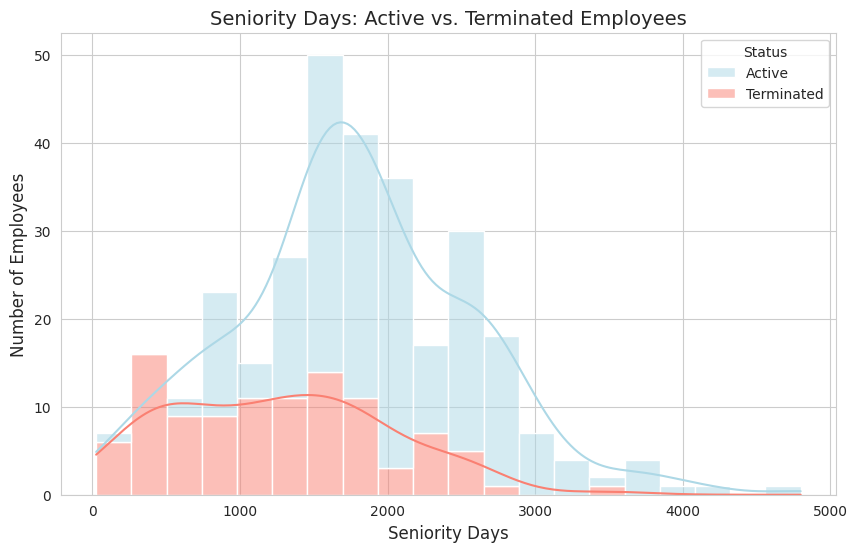

In [22]:
df['Status'] = df['Termd'].map({1: 'Terminated', 0: 'Active'})

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.histplot(
    data=df,
    x='Seniority_Days',
    hue='Status',
    multiple='stack',
    bins=20,
    kde=True,
    palette={'Active': 'lightblue', 'Terminated': 'salmon'}
)
plt.title('Seniority Days: Active vs. Terminated Employees', fontsize=14)
plt.xlabel('Seniority Days', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)

plt.show()
df = df.drop(columns=['Status'])

## DROP Columns

In [23]:
cols_to_drop = ['Employee_Name', 'EmpID', 'TermReason', 'DateofTermination',
                'DOB', 'DateofHire', 'LastPerformanceReview_Date',
                'MaritalStatusID', 'EmpStatusID', 'DeptID', 'PerfScoreID',
                'PositionID', 'EmploymentStatus','GenderID', 'Sex','HispanicLatino','ManagerName', 'RaceDesc']
df_model = df.drop(columns=cols_to_drop)
df_model.head(1)

,MarriedID,FromDiversityJobFairID,Salary,Termd,Position,State,Zip,MaritalDesc,CitizenDesc,Department,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,Seniority_Days
0,0,0,62506,0,Production Technician I,MA,1960,Single,US Citizen,Production,22.0,LinkedIn,Exceeds,4.6,5,0,0,1,2795


In [24]:
dfTerm.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'PositionID', 'Position', 'State', 'Zip', 'DOB', 'Sex',
       'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences'],
      dtype='object')

In [25]:
cols_to_drop = ['Employee_Name', 'EmpID', 'DateofTermination','LastPerformanceReview_Date', 'Department',
                'MaritalStatusID', 'EmpStatusID', 'PerfScoreID', 'RaceDesc',
                'EmploymentStatus','GenderID', 'Sex','HispanicLatino','ManagerName']
dfTerm = dfTerm.drop(columns=cols_to_drop)
dfTerm['DOB'] = pd.to_datetime(dfTerm['DOB'], format='%m/%d/%y')
dfTerm['DOByear'] = dfTerm['DOB'].dt.year
dfTerm['DateofHire'] = pd.to_datetime(dfTerm['DateofHire'], format='%m/%d/%Y')
dfTerm['HireYear'] = dfTerm['DateofHire'].dt.year

dfTerm.drop(columns=['DOB','DateofHire'], inplace=True)

dfTerm.head(1)

,MarriedID,DeptID,FromDiversityJobFairID,Salary,PositionID,Position,State,Zip,MaritalDesc,CitizenDesc,...,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,DOByear,HireYear
1,1,3,0,104437,27,Sr. DBA,MA,2148,Married,US Citizen,...,4.0,Indeed,Fully Meets,4.96,3,6,0,17,1975,2015


In [26]:
cols_to_drop = ['Employee_Name', 'EmpID', 'DateofTermination','LastPerformanceReview_Date', 'Department',
                'MaritalStatusID', 'EmpStatusID', 'PerfScoreID', 'RaceDesc',
                'EmploymentStatus','GenderID', 'Sex','HispanicLatino','ManagerName']
dfIn = dfIn.drop(columns=cols_to_drop)
dfIn['DOB'] = pd.to_datetime(dfIn['DOB'], format='%m/%d/%y')
dfIn['DOByear'] = dfIn['DOB'].dt.year
dfIn['DateofHire'] = pd.to_datetime(dfIn['DateofHire'], format='%m/%d/%Y')
dfIn['HireYear'] = dfIn['DateofHire'].dt.year

dfIn.drop(columns=['DOB','DateofHire'], inplace=True)

dfIn.head(1)

,MarriedID,DeptID,FromDiversityJobFairID,Salary,PositionID,Position,State,Zip,MaritalDesc,CitizenDesc,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,DOByear,HireYear
0,0,5,0,62506,19,Production Technician I,MA,1960,Single,US Citizen,22.0,LinkedIn,Exceeds,4.6,5,0,0,1,1983,2011


In [27]:
le = LabelEncoder()
categorical_cols = df_model.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))
df_model.head(15)

,MarriedID,FromDiversityJobFairID,Salary,Termd,Position,State,Zip,MaritalDesc,CitizenDesc,Department,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,Seniority_Days
0,0,0,62506,0,21,10,1960,3,2,3,22.0,5,0,4.60,5,0,0,1,2795
1,1,0,104437,1,29,10,2148,1,2,2,4.0,4,1,4.96,3,6,0,17,444
2,1,0,64955,1,22,10,1810,1,2,3,20.0,5,1,3.02,3,0,0,3,447
3,1,0,64991,0,21,10,1886,1,2,3,16.0,4,1,4.84,5,0,0,15,4070
4,0,0,50825,1,21,10,2169,0,2,3,39.0,3,1,5.00,4,0,0,2,1884
5,0,0,57568,0,21,10,1844,3,2,3,11.0,5,0,5.00,5,0,0,15,2607
6,0,0,95660,0,26,10,2110,3,2,5,10.0,5,1,3.04,3,4,0,19,1571
7,0,0,59365,0,21,10,2199,4,2,3,19.0,2,1,5.00,4,0,0,19,1977
8,0,1,47837,0,21,10,1902,3,2,3,12.0,1,1,4.46,3,0,0,4,3524
9,0,0,50178,0,16,10,1886,0,2,2,7.0,4,1,5.00,5,6,0,16,1515


## MODEL TRAINING

In [28]:
X = df_model.drop('Termd', axis=1)
y = df_model['Termd']

X = X.fillna(X.median())

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100,class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

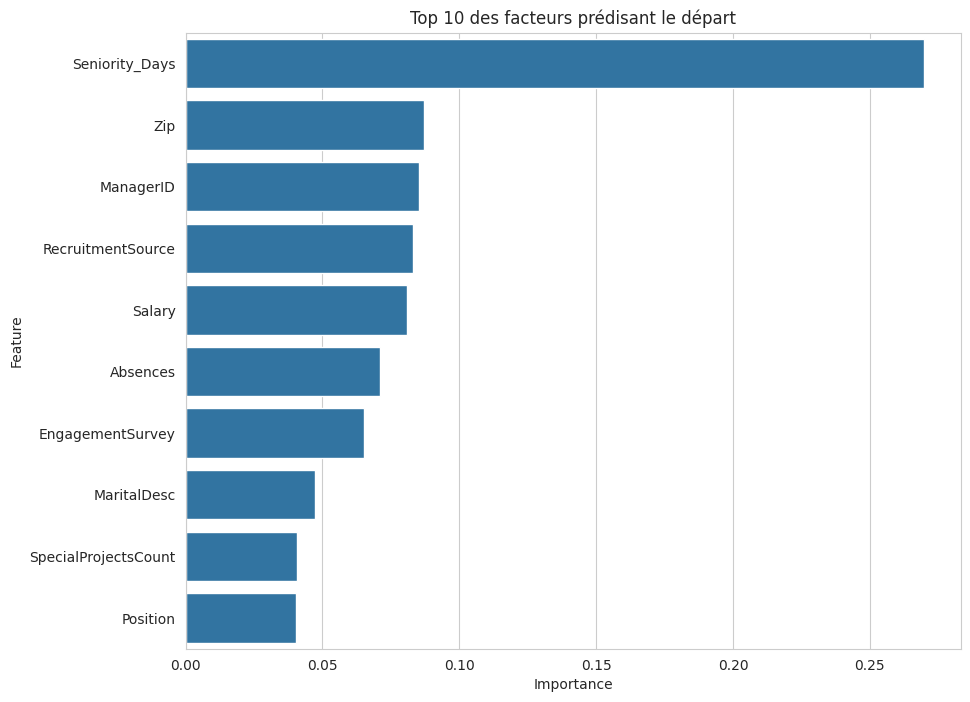


--- Top 5 des facteurs les plus influents ---
              Feature  Importance
17     Seniority_Days    0.269638
5                 Zip    0.087084
9           ManagerID    0.085161
10  RecruitmentSource    0.083123
2              Salary    0.080834


In [30]:
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 des facteurs prédisant le départ')
plt.show()

print("\n--- Top 5 des facteurs les plus influents ---")
print(feature_importance_df.head(5))

In [31]:
y_pred = rf_model.predict(X_test)

print(f"--- Performance du Modèle ---")
print(f"Précision globale (Accuracy) : {accuracy_score(y_test, y_pred):.2f}")
print("\n--- Rapport de Classification ---")
print(classification_report(y_test, y_pred))

--- Performance du Modèle ---
Précision globale (Accuracy) : 0.82

--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       0.83      0.94      0.88        66
           1       0.79      0.54      0.64        28

    accuracy                           0.82        94
   macro avg       0.81      0.74      0.76        94
weighted avg       0.82      0.82      0.81        94



In [32]:

individu_X = X_test.iloc[[0]]
vrai_statut = y_test.iloc[0]

probabilites = rf_model.predict_proba(individu_X)[0]

print(f"--- Analyse pour l'employé n°{X_test.index[0]} ---")
print(f"Confiance 'Reste' : {probabilites[0]*100:.1f}%")
print(f"Confiance 'Part'  : {probabilites[1]*100:.1f}%")
print(f"Statut Réel      : {'Parti' if vrai_statut == 1 else 'Actif'}")

--- Analyse pour l'employé n°290 ---
Confiance 'Reste' : 83.0%
Confiance 'Part'  : 17.0%
Statut Réel      : Actif


In [33]:
probabilites_totales = rf_model.predict_proba(X_test)

predictions_finales = rf_model.predict(X_test)
confiance_decision = probabilites_totales.max(axis=1) * 100

df_analyses = pd.DataFrame({
    'ID_Employe': X_test.index,

    'Prediction_Modele': ['Parti' if p == 1 else 'Actif' for p in predictions_finales],

    'Confiance_en_la_decision_%': confiance_decision.round(1),

    'Statut_Reel': ['Parti' if y == 1 else 'Actif' for y in y_test]
})

print(df_analyses.head(10))

   ID_Employe Prediction_Modele  Confiance_en_la_decision_% Statut_Reel
0         290             Actif                        83.0       Actif
1           9             Actif                        75.0       Actif
2          57             Actif                        85.0       Actif
3          60             Actif                        88.0       Actif
4          25             Actif                        66.0       Parti
5          63             Actif                        90.0       Actif
6          92             Actif                        83.0       Actif
7         184             Parti                        52.0       Actif
8         244             Actif                        73.0       Parti
9          46             Actif                        91.0       Parti


In [34]:
feature_importance_df

,Feature,Importance
17,Seniority_Days,0.269638
5,Zip,0.087084
9,ManagerID,0.085161
10,RecruitmentSource,0.083123
2,Salary,0.080834
16,Absences,0.071093
12,EngagementSurvey,0.065186
6,MaritalDesc,0.047439
14,SpecialProjectsCount,0.040681
3,Position,0.040479


## Second Model Training

In [35]:
dfTerm_model = dfTerm.copy()

In [36]:
X2 = dfTerm_model.drop('TermReason', axis=1)
y2 = dfTerm_model['TermReason']


In [37]:
dfTerm.head(1)

,MarriedID,DeptID,FromDiversityJobFairID,Salary,PositionID,Position,State,Zip,MaritalDesc,CitizenDesc,...,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,DOByear,HireYear
1,1,3,0,104437,27,Sr. DBA,MA,2148,Married,US Citizen,...,4.0,Indeed,Fully Meets,4.96,3,6,0,17,1975,2015


In [38]:
le = LabelEncoder()
categorical_cols = X2.select_dtypes(include=['object']).columns

for col in categorical_cols:
    X2[col] = le.fit_transform(X2[col].astype(str))
X2.head(1)

,MarriedID,DeptID,FromDiversityJobFairID,Salary,PositionID,Position,State,Zip,MaritalDesc,CitizenDesc,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,DOByear,HireYear
1,1,3,0,104437,27,13,1,2148,1,2,4.0,4,1,4.96,3,6,0,17,1975,2015


In [39]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=42)

In [40]:
rf_modelTerm = RandomForestClassifier(n_estimators=100,class_weight='balanced', random_state=42)
rf_modelTerm.fit(X2_train, y2_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

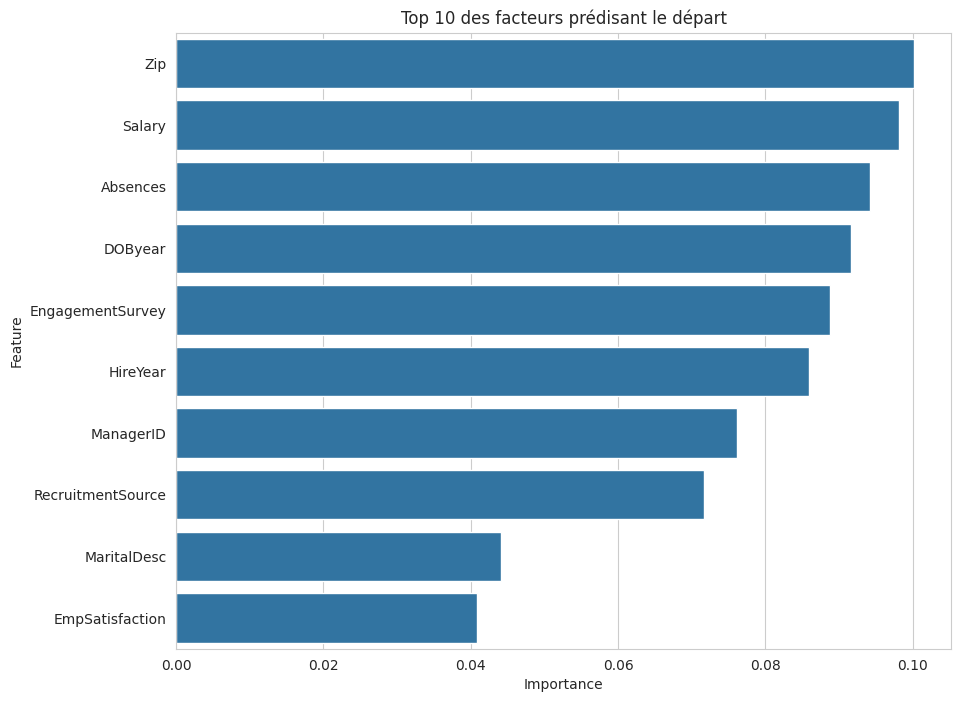


--- Top 5 des facteurs les plus influents ---
             Feature  Importance
7                Zip    0.100217
3             Salary    0.098088
17          Absences    0.094175
18           DOByear    0.091654
13  EngagementSurvey    0.088816


In [41]:
importances = rf_modelTerm.feature_importances_
feature_names = X2.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 des facteurs prédisant le départ')
plt.show()

print("\n--- Top 5 des facteurs les plus influents ---")
print(feature_importance_df.head(5))

In [42]:
y2_pred = rf_modelTerm.predict(X2_test)

print(f"--- Performance du Modèle ---")
print(f"Précision globale (Accuracy) : {accuracy_score(y2_test, y2_pred):.2f}")
print("\n--- Rapport de Classification ---")
print(classification_report(y2_test, y2_pred))

--- Performance du Modèle ---
Précision globale (Accuracy) : 0.06

--- Rapport de Classification ---
                                  precision    recall  f1-score   support

                Another position       0.12      0.67      0.21         3
                Fatal attraction       0.00      0.00      0.00         1
   Learned that he is a gangster       0.00      0.00      0.00         1
                      attendance       0.00      0.00      0.00         4
                   career change       0.00      0.00      0.00         3
                gross misconduct       0.00      0.00      0.00         1
                           hours       0.00      0.00      0.00         2
maternity leave - did not return       0.00      0.00      0.00         2
                  medical issues       0.00      0.00      0.00         2
                      more money       0.00      0.00      0.00         5
                no-call, no-show       0.00      0.00      0.00         1
          

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [43]:
y2_pred = pd.Series(y2_pred, index=y2_test.index, name='Predictions')
y2_pred

,Predictions
108,performance
216,Another position
215,career change
178,unhappy
157,Another position
289,Another position
285,Another position
161,Another position
27,hours
1,Another position


## Conclusion

In [44]:
le = LabelEncoder()
categorical_cols = dfIn.select_dtypes(include=['object']).columns

for col in categorical_cols:
    dfIn[col] = le.fit_transform(dfIn[col].astype(str))
dfIn.head(1)

,MarriedID,DeptID,FromDiversityJobFairID,Salary,PositionID,Position,State,Zip,MaritalDesc,CitizenDesc,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,DOByear,HireYear
0,0,5,0,62506,19,19,10,1960,3,2,22.0,5,0,4.6,5,0,0,1,1983,2011


In [45]:
Dfin_pred = rf_modelTerm.predict(dfIn)

In [46]:
Dfin_pred = pd.Series(Dfin_pred, index=dfIn.index, name='TermReason')
Dfin_pred

,TermReason
0,relocation out of area
3,more money
5,Another position
6,Another position
7,attendance
...,...
305,Another position
306,Another position
308,performance
309,Another position


In [47]:
dfajout = pd.read_csv('HRDataset_v14.csv')
dfajout['DOB'] = pd.to_datetime(dfajout['DOB'], format='%m/%d/%y')
dfajout['DOByear'] = dfajout['DOB'].dt.year
dfajout['DateofHire'] = pd.to_datetime(dfajout['DateofHire'], format='%m/%d/%Y')
dfajout['HireYear'] = dfajout['DateofHire'].dt.year

In [48]:
employes_a_risque = df_analyses[(df_analyses['Statut_Reel'] == 'Actif') &
                                (df_analyses['Prediction_Modele'] == 'Parti')].copy()

employes_a_risque = employes_a_risque.sort_values(by='Confiance_en_la_decision_%', ascending=False)

X_a_risque = X_test.loc[employes_a_risque['ID_Employe']]
X_a_risque.drop(columns=['Department', 'Seniority_Days'], inplace=True)
colonnes_manquantes = ['DOByear', 'DeptID', 'HireYear', 'PositionID']


X_a_risque[colonnes_manquantes] = dfajout.loc[X_a_risque.index, colonnes_manquantes]

ordre_attendu = rf_modelTerm.feature_names_in_
X_a_risque = X_a_risque[ordre_attendu]
X_a_risque.shape

(4, 20)

In [49]:

employes_a_risque['Raison_Estimee'] = rf_modelTerm.predict(X_a_risque)
alertes_rh = employes_a_risque.merge(df[['Employee_Name', 'Department', 'ManagerName']],
                                     left_on='ID_Employe',
                                     right_index=True,
                                     how='left')
nombre_total_risque = len(alertes_rh)

print(f"ALERTE : {nombre_total_risque} employés sont actuellement à risque de départ !")
print("\n" + "="*50 + "\n")

print("LISTE COMPLÈTE DES EMPLOYÉS À RETENIR EN PRIORITÉ ")
print(alertes_rh[['Employee_Name', 'Department', 'Confiance_en_la_decision_%', 'Raison_Estimee']])

print("\n" + "-"*50 + "\n")

synthese_motifs = alertes_rh['Raison_Estimee'].value_counts().reset_index()
synthese_motifs.columns = ['Motif de départ estimé', "Nombre d'employés à risque"]

print("SYNTHÈSE DES RISQUES DE DÉPART PAR MOTIF :")
print(synthese_motifs)

ALERTE : 4 employés sont actuellement à risque de départ !


LISTE COMPLÈTE DES EMPLOYÉS À RETENIR EN PRIORITÉ 
          Employee_Name     Department  Confiance_en_la_decision_%  \
18  LeBlanc, Brandon  R  Admin Offices                        63.0   
32         England, Rex     Production                        54.0   
7         McKinzie, Jac          Sales                        52.0   
84    Fernandes, Nilson     Production                        52.0   

      Raison_Estimee  
18    medical issues  
32  Another position  
7         attendance  
84  no-call, no-show  

--------------------------------------------------

SYNTHÈSE DES RISQUES DE DÉPART PAR MOTIF :
  Motif de départ estimé  Nombre d'employés à risque
0         medical issues                           1
1       Another position                           1
2             attendance                           1
3       no-call, no-show                           1


Fichier HTML généré


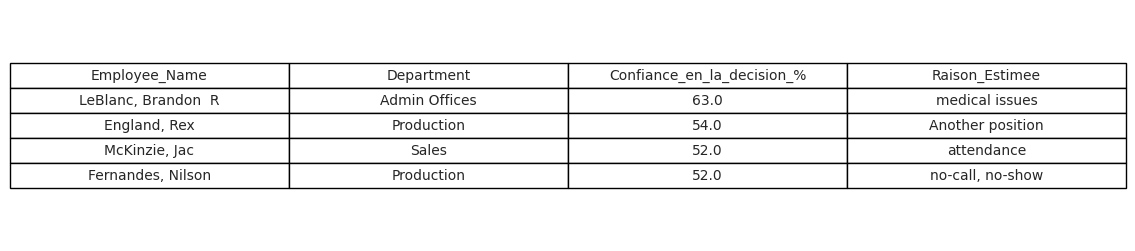

In [50]:
colonnes_pdf = ['Employee_Name', 'Department', 'Confiance_en_la_decision_%', 'Raison_Estimee']
donnees_a_exporter = alertes_rh[colonnes_pdf]
fig, ax = plt.subplots(figsize=(12, len(donnees_a_exporter) * 0.5 + 1))
ax.axis('tight')
ax.axis('off')
tableau = ax.table(cellText=donnees_a_exporter.values,
                   colLabels=donnees_a_exporter.columns,
                   loc='center',
                   cellLoc='center')

tableau.auto_set_font_size(False)
tableau.set_fontsize(10)
tableau.scale(1.2, 1.5)
alertes_rh[colonnes_pdf].to_html("Rapport_Temporaire.html", index=False)

print("Fichier HTML généré")
plt.savefig("Rapport_Risques_Depart_RH.pdf", bbox_inches='tight')

## INPUT

In [51]:
df_input = pd.read_csv('HRDataset_v14.csv') #a remplacer
df_input.head(1)

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.6,5,0,1/17/2019,0,1


In [52]:
df_input['DateofHire'] = pd.to_datetime(df_input['DateofHire'], errors="coerce")
df_input['DateofTermination'] = pd.to_datetime(df_input['DateofTermination'], errors="coerce")
df_input['LastPerformanceReview_Date'] = pd.to_datetime(df_input['LastPerformanceReview_Date'], errors="coerce")

In [53]:
seniority_end_date_input = df_input['DateofTermination'].where(df_input['Termd'] == 1, today)
df_input['Seniority_Days'] = (seniority_end_date_input - df_input['DateofHire']).dt.days

In [54]:
dfTerm_input = df[df['Termd'] != 0]
dfTerm_input.drop(columns=['Termd'], inplace=True)
dfIn_input = df[df['Termd'] != 1]
dfIn_input.drop(columns=['Termd'], inplace=True)
dfIn_input.drop(columns=['TermReason'],inplace = True)

/tmp/ipykernel_7350/4255948065.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfTerm_input.drop(columns=['Termd'], inplace=True)
/tmp/ipykernel_7350/4255948065.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfIn_input.drop(columns=['Termd'], inplace=True)
/tmp/ipykernel_7350/4255948065.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfIn_input.drop(columns=['TermReason'],inplace = True)


In [55]:
df_input['DOB'] = pd.to_datetime(df_input['DOB'], format='%m/%d/%y')
df_input['DOByear'] = df_input['DOB'].dt.year
df_input['DateofHire'] = pd.to_datetime(df_input['DateofHire'], format='%m/%d/%Y')
df_input['HireYear'] = df_input['DateofHire'].dt.year

In [56]:
status = df_input['Termd']

In [57]:
df_input.drop(columns=['TermReason','Termd','DateofTermination'], inplace=True, errors='ignore')

In [58]:
df_input_reason = df_input.copy()

In [59]:
cols_to_drop_reason = ['Employee_Name', 'EmpID', 'DateofTermination','LastPerformanceReview_Date', 'Department',
                'MaritalStatusID', 'EmpStatusID', 'PerfScoreID', 'RaceDesc',
                'EmploymentStatus','GenderID', 'Sex','HispanicLatino','ManagerName', 'DOB','DateofHire','Seniority_Days']
df_input_reason.drop(columns = cols_to_drop_reason, inplace=True, errors= 'ignore')

In [60]:
cols_to_drop = ['Employee_Name', 'EmpID', 'DateofTermination','LastPerformanceReview_Date', 'DeptID', 'DOByear','HireYear','PositionID',
                'MaritalStatusID', 'EmpStatusID', 'PerfScoreID', 'RaceDesc',
                'EmploymentStatus','GenderID', 'Sex','HispanicLatino','ManagerName', 'DOB','DateofHire']
df_input.drop(columns = cols_to_drop, inplace=True, errors= 'ignore')

In [61]:
df_input_reason.columns

Index(['MarriedID', 'DeptID', 'FromDiversityJobFairID', 'Salary', 'PositionID',
       'Position', 'State', 'Zip', 'MaritalDesc', 'CitizenDesc', 'ManagerID',
       'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey',
       'EmpSatisfaction', 'SpecialProjectsCount', 'DaysLateLast30', 'Absences',
       'DOByear', 'HireYear'],
      dtype='object')

In [62]:
le = LabelEncoder()
categorical_cols = df_input_reason.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df_input_reason[col] = le.fit_transform(df_input_reason[col].astype(str))
df_input_reason.head(1)

,MarriedID,DeptID,FromDiversityJobFairID,Salary,PositionID,Position,State,Zip,MaritalDesc,CitizenDesc,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,DOByear,HireYear
0,0,5,0,62506,19,22,10,1960,3,2,22.0,5,0,4.6,5,0,0,1,1983,2011


In [63]:
le = LabelEncoder()
categorical_cols = df_input.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df_input[col] = le.fit_transform(df_input[col].astype(str))
df_input.head(1)

,MarriedID,FromDiversityJobFairID,Salary,Position,State,Zip,MaritalDesc,CitizenDesc,Department,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,Seniority_Days
0,0,0,62506,22,10,1960,3,2,3,22.0,5,0,4.6,5,0,0,1,2795


In [64]:
input_pred_reason = rf_modelTerm.predict(df_input_reason)

In [67]:
input_proba = rf_model.predict_proba(df_input)

pred_input = rf_model.predict(df_input)
confiance_decision = input_proba.max(axis=1) * 100

df_analyses_input = pd.DataFrame({
    'ID_Employe': df_input.index,

    'Prediction_Modele': ['Parti' if p == 1 else 'Actif' for p in pred_input],

    'Confiance_en_la_decision_%': confiance_decision.round(1),

    'Statut_Reel': ['Parti' if y == 1 else 'Actif' for y in status]
})

print(df_analyses_input.head(10))

   ID_Employe Prediction_Modele  Confiance_en_la_decision_% Statut_Reel
0           0             Actif                        93.0       Actif
1           1             Parti                        77.0       Parti
2           2             Parti                        80.0       Parti
3           3             Actif                        95.0       Actif
4           4             Parti                        88.0       Parti
5           5             Actif                        87.0       Actif
6           6             Actif                        74.0       Actif
7           7             Actif                        60.0       Actif
8           8             Actif                        93.0       Actif
9           9             Actif                        75.0       Actif


In [70]:
employes_a_risque_input = df_analyses[(df_analyses_input['Statut_Reel'] == 'Actif') &
                                (df_analyses_input['Prediction_Modele'] == 'Parti')].copy()

employes_a_risque_input = employes_a_risque_input.sort_values(by='Confiance_en_la_decision_%', ascending=False)

X_a_risque_input = df_input.loc[employes_a_risque_input['ID_Employe']]
X_a_risque_input.drop(columns=['Department', 'Seniority_Days'], inplace=True)
colonnes_manquantes_input = ['DOByear', 'DeptID', 'HireYear', 'PositionID']
X_a_risque_input[colonnes_manquantes_input] = dfajout.loc[X_a_risque_input.index, colonnes_manquantes_input]

#ordre_attendu = rf_modelTerm.feature_names_in_
X_a_risque_input = X_a_risque_input[ordre_attendu]
X_a_risque_input.shape

/tmp/ipykernel_7350/3576662330.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  employes_a_risque_input = df_analyses[(df_analyses_input['Statut_Reel'] == 'Actif') &


(2, 20)

In [71]:
employes_a_risque_input['Raison_Estimee'] = rf_modelTerm.predict(X_a_risque_input)
alertes_rh_input = employes_a_risque_input.merge(df[['Employee_Name', 'Department', 'ManagerName']],
                                     left_on='ID_Employe',
                                     right_index=True,
                                     how='left')
nombre_total_risque_input = len(alertes_rh_input)

print(f"ALERTE : {nombre_total_risque_input} employés sont actuellement à risque de départ !")
print("\n" + "="*50 + "\n")

print("LISTE COMPLÈTE DES EMPLOYÉS À RETENIR EN PRIORITÉ ")
print(alertes_rh_input[['Employee_Name', 'Department', 'Confiance_en_la_decision_%', 'Raison_Estimee']])

print("\n" + "-"*50 + "\n")

synthese_motifs = alertes_rh_input['Raison_Estimee'].value_counts().reset_index()
synthese_motifs.columns = ['Motif de départ estimé', "Nombre d'employés à risque"]

print("SYNTHÈSE DES RISQUES DE DÉPART PAR MOTIF :")
print(synthese_motifs)

ALERTE : 2 employés sont actuellement à risque de départ !


LISTE COMPLÈTE DES EMPLOYÉS À RETENIR EN PRIORITÉ 
      Employee_Name  Department  Confiance_en_la_decision_%    Raison_Estimee
90    Becker, Scott  Production                        91.0  Another position
82  Johnson, Noelle       IT/IS                        83.0  no-call, no-show

--------------------------------------------------

SYNTHÈSE DES RISQUES DE DÉPART PAR MOTIF :
  Motif de départ estimé  Nombre d'employés à risque
0       Another position                           1
1       no-call, no-show                           1


Fichier HTML généré


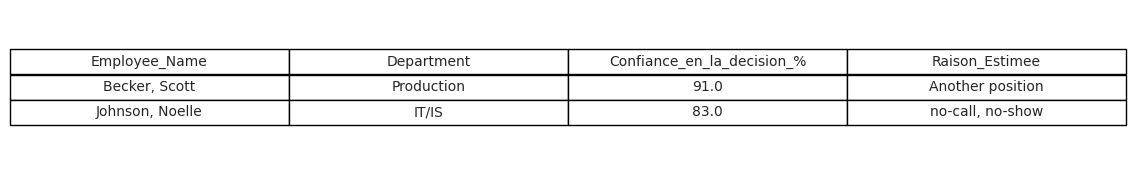

In [72]:
donnees_a_exporter = alertes_rh_input[colonnes_pdf]
fig, ax = plt.subplots(figsize=(12, len(donnees_a_exporter) * 0.5 + 1))
ax.axis('tight')
ax.axis('off')
tableau = ax.table(cellText=donnees_a_exporter.values,
                   colLabels=donnees_a_exporter.columns,
                   loc='center',
                   cellLoc='center')

tableau.auto_set_font_size(False)
tableau.set_fontsize(10)
tableau.scale(1.2, 1.5)
alertes_rh_input[colonnes_pdf].to_html("Rapport_Temporaire.html", index=False)

print("Fichier HTML généré")
plt.savefig("Rapport_Risques_Depart_RH.pdf", bbox_inches='tight')